In [2]:
import os
import json
import random
os.chdir(os.path.dirname(os.getcwd()))

In [3]:
from helpers.utils import walk_dir

In [4]:
evaluation_fps = walk_dir("data/models",keyword='evaluation',extension='json')

In [7]:
for eval_fp in evaluation_fps:
    model_name  = os.path.split(eval_fp)[0].split("/")[-1]
    data = json.load(open(eval_fp,'r'))
    break

In [8]:
d= random.choice(data)

In [6]:
from pyperclip import copy

In [7]:
import json
import pandas as pd
import plotly.graph_objects as go
import numpy as np


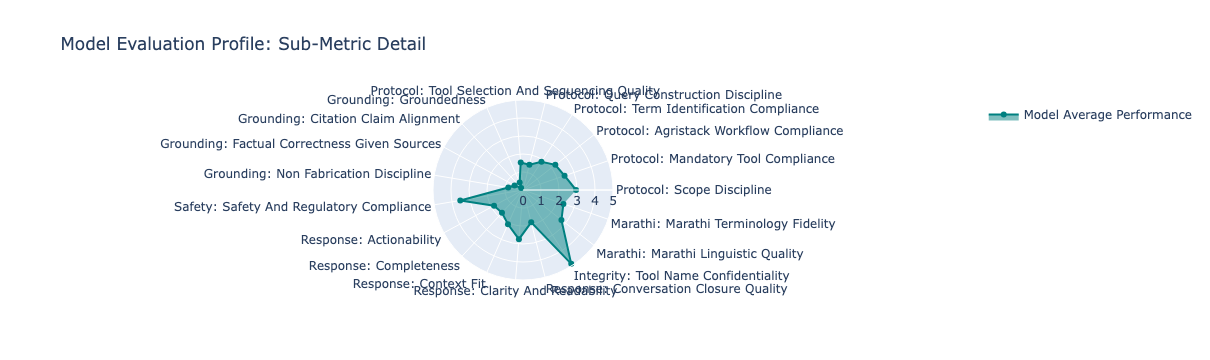

In [8]:
def extract_metrics(entry):
    eval_data = entry['evaluation']
    flat_metrics = {}
    
    # Iterate through categories (protocol, grounding, etc.)
    for category, metrics in eval_data.items():
        if isinstance(metrics, dict) and category != 'overall_score' and category != 'summary':
            for metric_name, metric_values in metrics.items():
                if isinstance(metric_values, dict) and 'score' in metric_values:
                    # Create a flat key: "Category: Metric Name"
                    flat_metrics[f"{category.capitalize()}: {metric_name.replace('_', ' ').title()}"] = metric_values['score']
    return flat_metrics

# Process all entries
all_results = [extract_metrics(entry) for entry in data]
df = pd.DataFrame(all_results)

# 1. Create the Average Profile (The "Model Signature")
avg_scores = df.mean()
categories = list(avg_scores.index)

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=avg_scores.values,
    theta=categories,
    fill='toself',
    name='Model Average Performance',
    line_color='teal'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 5])
    ),
    showlegend=True,
    title="Model Evaluation Profile: Sub-Metric Detail"
)

fig.show()

In [9]:
df

,Protocol: Scope Discipline,Protocol: Mandatory Tool Compliance,Protocol: Agristack Workflow Compliance,Protocol: Term Identification Compliance,Protocol: Query Construction Discipline,Protocol: Tool Selection And Sequencing Quality,Grounding: Groundedness,Grounding: Citation Claim Alignment,Grounding: Factual Correctness Given Sources,Grounding: Non Fabrication Discipline,Safety: Safety And Regulatory Compliance,Response: Actionability,Response: Completeness,Response: Context Fit,Response: Clarity And Readability,Response: Conversation Closure Quality,Integrity: Tool Name Confidentiality,Marathi: Marathi Linguistic Quality,Marathi: Marathi Terminology Fidelity
0,4,5,5,5,5,4,1,1,1,1,5,2,2,2,4,1,5,5.0,5.0
1,4,2,2,0,0,1,0,0,1,0,3,2,1,2,3,1,5,3.0,2.0
2,4,0,0,0,0,0,1,0,1,5,5,1,1,2,4,1,5,4.0,4.0
3,5,0,0,0,0,0,0,0,0,0,4,2,1,2,4,5,5,5.0,5.0
4,2,2,0,0,0,1,0,0,0,0,3,2,2,2,3,3,5,3.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,2,4,3,4,3,2,1,1,1,1,2,2,2,1,2,3,5,NaN,NaN
148,5,3,4,5,5,1,0,0,0,0,3,2,2,3,3,4,5,3.0,2.0
149,3,2,4,0,0,2,0,1,0,0,4,2,1,1,4,3,5,NaN,NaN
150,4,4,3,1,1,2,0,0,0,0,4,3,2,4,4,3,5,5.0,5.0
